# CS6472 – Research Methods and Specifications
## Assessment 4 – Group Project | PS15: Learning From Limited Data in Energy Modelling
___
### Research Question: PS15

###In many real-world scenarios, only limited historical energy data may be available. Developing effective models under data scarcity is a practical challenge. This problem focuses on machine learning approaches that perform well with small datasets. Overfitting and generalisation are central concerns. The goal is to identify strategies that maximise learning efficiency. This reflects constraints faced in many applied settings

## 1. Imports & Global Style Settings

We import all necessary libraries here.
The colorblind-safe palette (cb_palette) is applied globally so every plot in this notebook is accessible to colour-blind readers.

In [1]:
import pandas as pd
import numpy as np
import requests

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

#Colorblind friendly palette (applied globally)
cb_palette = ["#D81B60", "#1E88E5", "#FFC107", "#004D40"]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cb_palette)

pd.set_option('display.max_columns', None)

## 2. Load Datasets

Three datasets are used:
- **kaggle** : the large public household energy dataset (90,000 rows, 7 features)
- **synthetic** : the student-collected synthetic dataset (390 rows; has a County column but lacks Household_Size and Peak_Hours_Usage_kWh)
- **test** : the unlabelled test set for the Kaggle competition submission


In [2]:
kaggle = pd.read_csv("household_energy_consumption.csv")
synthetic = pd.read_csv("synthetic_release.csv")
test = pd.read_csv("test_data.csv")

In [3]:
print("Kaggle shape:", kaggle.shape)
print("Synthetic shape:", synthetic.shape)
print("Test shape:", test.shape)

kaggle.head()

Kaggle shape: (90000, 7)
Synthetic shape: (390, 5)
Test shape: (390, 5)


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


In [4]:
synthetic.head()

,Household_ID,Date,County,Energy_Consumption_kWh,Has_AC
0,S596,2026-03-06,Ireland,0.25,No
1,S588,2026-02-19,Ireland,0.14,No
2,S544,2026-02-18,Limerick,2.33,No
3,S645,2026-03-27,Clare,1.32,No
4,S488,2026-03-02,Limerick,3.17,No


In [5]:
test.head()

,Household_ID,Date,County,Has_AC,Avg_Temperature_C
0,S108,18/02/2026,Limerick,No,9.60
1,S60,01/03/2026,limerick,No,8.43
2,S587,20/02/2026,Ireland,No,6.87
3,S537,08/03/2026,Cork,No,8.97
4,S101,16/03/2026,Limerick,No,11.02


## 3. Exploratory Data Analysis (EDA)

Before any cleaning, we visualise the target variable distribution in the Kaggle dataset.
Understanding the spread of Energy_Consumption_kWh helps us choose an appropriate evaluation metric (RMSE) and spot any extreme skew.

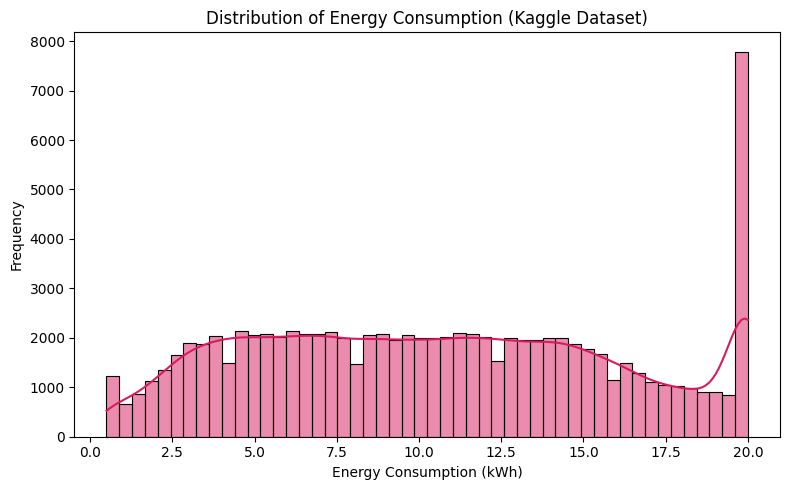

count    90000.000000
mean        10.571988
std          5.519494
min          0.500000
25%          6.000000
50%         10.400000
75%         14.800000
max         20.000000
Name: Energy_Consumption_kWh, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram with KDE using the first colorblind-safe colour
sns.histplot(
    kaggle['Energy_Consumption_kWh'],
    kde=True,
    color=cb_palette[0],
    ax=ax
)
ax.set_title("Distribution of Energy Consumption (Kaggle Dataset)")
ax.set_xlabel("Energy Consumption (kWh)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print(kaggle['Energy_Consumption_kWh'].describe())

## 4. Data Cleaning of County Column

The County column in both the synthetic and test datasets is free-text and contains many misspellings, extra whitespace, and non-county values (e.g. 'school', 'iPhone ', 'home').

We define a cleaning function that:
1. Lower-cases and strips whitespace
2. Applies a manual typo-correction map (e.g. 'limerck' -> 'limerick')
3. Checks whether any known Irish county name appears as a substring
4. Returns None for values that match nothing (to be imputed with the mode)

In [7]:
# Inspect raw unique county values before cleaning
print("Raw County values in synthetic:")
print(synthetic['County'].unique())

Raw County values in synthetic:
['Ireland' 'Limerick ' 'Clare' 'Limerick' 'iPhone ' 'limerick' 'Roscommon'
 'Limerick, Ireland' 'Dromroe Village,Oak house,Limerick' 'Galway' 'Cork'
 'Limerck ' 'galway' 'Mayo' 'school' 'Co Clare' 'Waterford ' 'Dublin '
 'Waterford' 'LIMERICK' 'Ireland ' 'Mobile phone (Ireland) (4hours)'
 'home' 'Limmerick']


In [8]:
# All 26 Irish counties (lowercase for matching)
known_counties = [
    'limerick', 'cork', 'dublin', 'galway', 'clare',
    'tipperary', 'waterford', 'kilkenny', 'wexford',
    'mayo', 'roscommon', 'sligo', 'leitrim', 'donegal',
    'monaghan', 'cavan', 'longford', 'westmeath',
    'meath', 'louth', 'kildare', 'wicklow', 'carlow',
    'laois', 'offaly'
]

def clean_county_col(raw):
    """Standardise a raw County string to a capitalised county name.
    Returns None if no known county can be matched.
    """
    if pd.isna(raw):
        return None

    lower = str(raw).strip().lower()

    # Fixing known typos
    typo_map = {
        'limerck':'limerick',
        'limmerick': 'limerick',
    }
    for typo, fix in typo_map.items():
        lower = lower.replace(typo, fix)

    # Return the first county name found as a substring
    for county in known_counties:
        if county in lower:
            return county.capitalize()
    return None # Non-county entries (e.g. 'school', 'iPhone')

# Apply cleaning
synthetic['County'] = synthetic['County'].apply(clean_county_col)

# Impute unrecognised values with the mode
mode_county = synthetic['County'].mode()[0]
n_missing   = synthetic['County'].isna().sum()

print(f'Mode county used for imputation: {mode_county}')
print(f'Rows imputed: {n_missing}')

synthetic['County'] = synthetic['County'].fillna(mode_county)

print('\n--- Cleaned County value counts ---')
print(synthetic['County'].value_counts())

Mode county used for imputation: Limerick
Rows imputed: 28

--- Cleaned County value counts ---
County
Limerick     352
Galway         9
Cork           9
Roscommon      8
Clare          7
Mayo           2
Waterford      2
Dublin         1
Name: count, dtype: int64


In [9]:
print(synthetic['County'].unique())

['Limerick' 'Clare' 'Roscommon' 'Galway' 'Cork' 'Mayo' 'Waterford'
 'Dublin']


## 5. Date Parsing & Temporal Feature Engineering

Dates are stored in different formats across the three datasets:
- **Kaggle**: YYYY-MM-DD (ISO format)
- **Synthetic**: YYYY-MM-DD (ISO format)
- **Test**: DD/MM/YYYY (day-first)

After parsing, we extract two new features:
- **Month** : captures seasonal patterns in energy usage
- **DayOfWeek** : captures weekday vs. weekend effects (0 = Monday, 6 = Sunday)

In [10]:
kaggle['Date'] = pd.to_datetime(kaggle['Date'])
synthetic['Date'] = pd.to_datetime(synthetic['Date'])
test['Date'] = pd.to_datetime(test['Date'], dayfirst=True)

In [11]:
def add_date_features(df):
    """Adding Month and DayOfWeek columns derived from the Date column."""
    df = df.copy()
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    return df

kaggle = add_date_features(kaggle)
synthetic = add_date_features(synthetic)
test = add_date_features(test)

print("Date features added. Sample (kaggle):")
kaggle[['Date', 'Month', 'DayOfWeek']].head()


Date features added. Sample (kaggle):


,Date,Month,DayOfWeek
0,2025-04-01,4,1
1,2025-04-02,4,2
2,2025-04-03,4,3
3,2025-04-04,4,4
4,2025-04-05,4,5


## 6. Missing Feature Imputation for Synthetic & Test Sets

The synthetic and test datasets lack Household_Size and Peak_Hours_Usage_kWh.

- **Household_Size** : set to 1 for all synthetic and test rows (student participants in the data collecting form are typically single occupants)
- **Peak_Hours_Usage_kWh** : calculated the **mean** from the Kaggle training data to avoid data leakage

In [12]:
# Household_Size: single occupant assumption for student data
synthetic['Household_Size'] = 1
test['Household_Size']      = 1

# Peak hours: calculated with Kaggle training mean
mean_peak = kaggle['Peak_Hours_Usage_kWh'].mean()
synthetic['Peak_Hours_Usage_kWh'] = mean_peak
test['Peak_Hours_Usage_kWh']      = mean_peak

print(f"Mean Peak_Hours_Usage_kWh used for imputation: {mean_peak:.4f}")

Mean Peak_Hours_Usage_kWh used for imputation: 4.3196


In [13]:
synthetic.head()

,Household_ID,Date,County,Energy_Consumption_kWh,Has_AC,Month,DayOfWeek,Household_Size,Peak_Hours_Usage_kWh
0,S596,2026-03-06,Limerick,0.25,No,3,4,1,4.319557
1,S588,2026-02-19,Limerick,0.14,No,2,3,1,4.319557
2,S544,2026-02-18,Limerick,2.33,No,2,2,1,4.319557
3,S645,2026-03-27,Clare,1.32,No,3,4,1,4.319557
4,S488,2026-03-02,Limerick,3.17,No,3,0,1,4.319557


## 7. Temperature Retrieval via Open-Meteo API

The synthetic dataset contain a County column but no temperature readings.
We query the [Open-Meteo Archive API](https://archive-api.open-meteo.com/) to obtain the **mean daily temperature** (temperature_2m_mean) for each unique (County, Date) pair.

To efficiently fetch daily temperature data for our dataset, we optimized the process by identifying and querying only unique (County, Date) pairs. This significantly reduced the number of API calls required, improving performance and lowering the risk of rate‑limit issues.

In [14]:
def get_daily_temperature(lat, lon, date):
    """Return the mean daily temperature (°C) from the Open-Meteo archive API.

    Parameters
    ----------
    lat, lon : float  : Latitude / longitude of the county centroid
    date     : str    : Date string in YYYY-MM-DD format

    Returns
    -------
    float | np.nan
    """
    url = (
        "https://archive-api.open-meteo.com/v1/archive?"
        f"latitude={lat}&longitude={lon}"
        f"&start_date={date}&end_date={date}"
        "&daily=temperature_2m_mean"
        "&timezone=auto"
    )
    try:
        response = requests.get(url, timeout=10).json()
        return response['daily']['temperature_2m_mean'][0]
    except Exception:
        return np.nan

In [15]:
# Geographic centroids for each Irish county
county_coords = {
    "Limerick": (52.6638, -8.6267),
    "Dublin": (53.3498, -6.2603),
    "Cork": (51.8985, -8.4756),
    "Galway": (53.2707, -9.0568),
    "Waterford": (52.2593, -7.1101),
    "Kilkenny": (52.6541, -7.2448),
    "Wexford": (52.3369, -6.4623),
    "Kerry": (52.1545, -9.5669),
    "Clare": (52.9045, -8.9810),
    "Mayo": (53.8000, -9.5333),
    "Sligo": (54.2697, -8.4694),
    "Roscommon": (53.6270, -8.1891),
    "Donegal": (54.6549, -8.1100),
    "Leitrim": (54.3070, -8.0000),
    "Longford": (53.7275, -7.7939),
    "Westmeath": (53.5333, -7.3500),
    "Offaly": (53.2734, -7.4906),
    "Laois": (53.0320, -7.3000),
    "Kildare": (53.1589, -6.9095),
    "Meath": (53.6055, -6.6564),
    "Louth": (53.9500, -6.5400),
    "Monaghan": (54.2500, -6.9667),
    "Cavan": (53.9908, -7.3606),
    "Tipperary": (52.4735, -8.1615),
    "Carlow": (52.8365, -6.9341),
    "Wicklow": (52.9800, -6.0400)
}


In [16]:
def fetch_temperatures(df):
    """Fetch Avg_Temperature_C for every unique (County, Date) pair in df.

    Merges the temperatures back into the original dataframe.
    """
    unique_pairs = df[['County', 'Date']].drop_duplicates().copy()
    unique_pairs['Date_str'] = unique_pairs['Date'].dt.strftime("%Y-%m-%d")

    # Map coordinates
    unique_pairs['lat'] = unique_pairs['County'].map(lambda c: county_coords[c][0])
    unique_pairs['lon'] = unique_pairs['County'].map(lambda c: county_coords[c][1])

    # One API call per unique (county, date) pair
    unique_pairs['Avg_Temperature_C'] = unique_pairs.apply(
        lambda row: get_daily_temperature(row['lat'], row['lon'], row['Date_str']),
        axis=1
    )

    # Merge temperatures back
    df = df.merge(
        unique_pairs[['County', 'Date', 'Avg_Temperature_C']],
        on=['County', 'Date'],
        how='left'
    )
    return df


synthetic = fetch_temperatures(synthetic)

print("Temperature fetching complete.")
print(f"Synthetic NaN temperatures: {synthetic['Avg_Temperature_C'].isna().sum()}")

Temperature fetching complete.
Synthetic NaN temperatures: 0


In [17]:
# County is no longer needed as a model feature
synthetic.drop(columns=['County'], inplace=True)
test.drop(columns=['County'], inplace=True)

In [18]:
print("Column alignment:")
print("Kaggle columns:   ", list(kaggle.columns))
print("Synthetic columns:", list(synthetic.columns))
print("Test columns:     ", list(test.columns))

Column alignment:
Kaggle columns:    ['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'Month', 'DayOfWeek']
Synthetic columns: ['Household_ID', 'Date', 'Energy_Consumption_kWh', 'Has_AC', 'Month', 'DayOfWeek', 'Household_Size', 'Peak_Hours_Usage_kWh', 'Avg_Temperature_C']
Test columns:      ['Household_ID', 'Date', 'Has_AC', 'Avg_Temperature_C', 'Month', 'DayOfWeek', 'Household_Size', 'Peak_Hours_Usage_kWh']


## 8. Encode Categorical Features

Has_AC is a binary Yes/No column. We encode it with LabelEncoder (No-> 0, Yes -> 1).
The encoder is **fit** on the Kaggle dataset (which contains both values) then **transformed** on the synthetic and test sets to avoid leakage.

In [19]:
le = LabelEncoder()

kaggle['Has_AC']    = le.fit_transform(kaggle['Has_AC'])      # fit + transform
synthetic['Has_AC'] = le.transform(synthetic['Has_AC'])       # transform only
test['Has_AC']      = le.transform(test['Has_AC'])            # transform only

print("Label encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


## 9. Merge Training Data & Define Feature Set

We concatenate the Kaggle and synthetic datasets into a single training frame.

**Features used:**
| Feature | Description |
|---|---|
| Household_Size | Number of occupants |
| Avg_Temperature_C | Mean daily temperature (°C) |
| Has_AC | Air-conditioning present (0/1) |
| Peak_Hours_Usage_kWh | Energy consumed during peak hours |
| Month | Month of year (1–12) |
| DayOfWeek | Day of week (0 = Monday, 6 = Sunday) |

**Target:** Energy_Consumption_kWh

In [20]:
train_full = pd.concat([kaggle, synthetic], ignore_index=True)
print(f"Combined training set shape: {train_full.shape}")
print(f"  - Kaggle rows:    {len(kaggle)}")
print(f"  - Synthetic rows: {len(synthetic)}")

Combined training set shape: (90390, 9)
  - Kaggle rows:    90000
  - Synthetic rows: 390


In [21]:
train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90390 entries, 0 to 90389
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Household_ID            90390 non-null  object        
 1   Date                    90390 non-null  datetime64[ns]
 2   Energy_Consumption_kWh  90390 non-null  float64       
 3   Household_Size          90390 non-null  int64         
 4   Avg_Temperature_C       90390 non-null  float64       
 5   Has_AC                  90390 non-null  int64         
 6   Peak_Hours_Usage_kWh    90390 non-null  float64       
 7   Month                   90390 non-null  int32         
 8   DayOfWeek               90390 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(2), object(1)
memory usage: 5.5+ MB


In [22]:
# Drop non-predictive identifier columns before modelling
train_full = train_full.drop(columns=['Household_ID', 'Date'])
test_model = test.drop(columns=['Household_ID', 'Date'])

FEATURES = [
    'Household_Size',
    'Avg_Temperature_C',
    'Has_AC',
    'Peak_Hours_Usage_kWh',
    'Month',
    'DayOfWeek'
]

TARGET = 'Energy_Consumption_kWh'

print(f"Number of features: {len(FEATURES)}")
print(f"Features: {FEATURES}")

Number of features: 6
Features: ['Household_Size', 'Avg_Temperature_C', 'Has_AC', 'Peak_Hours_Usage_kWh', 'Month', 'DayOfWeek']


In [23]:
# Train / validation split (80/20)
X = train_full[FEATURES]
y = train_full[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")

Training set:   72312 rows
Validation set: 18078 rows


## 10. Baseline Model Training

We train four baseline regression models, all with default or lightly tuned hyperparameters:

| Model | Notes |
|---|---|
| **Linear Regression** | Simple linear baseline |
| **Random Forest** | Ensemble of decision trees (300 estimators) |
| **Gradient Boosting** | Sequential boosting (sklearn default) |
| **XGBoost** | Extreme Gradient Boosting (300 estimators, lr = 0.05, depth = 6) |

Performance is measured with **Root Mean Squared Error (RMSE)** – the competition metric.

###A) Linear Regression



In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)

###B) Random Forest

In [25]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)

###C) Gradient Boosting

In [26]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_preds = gbr.predict(X_val)

###D) XGBoost

In [27]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_val)

## 11. Evaluate Baselines with RMSE

Lower RMSE = better predictions. The winning model will be used as the starting point for our research experiment.

In [28]:
def rmse(y_true, y_pred):
    """Compute Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


results = {
    'Linear Regression':  rmse(y_val, lr_preds),
    'Random Forest':      rmse(y_val, rf_preds),
    'Gradient Boosting':  rmse(y_val, gbr_preds),
    'XGBoost':            rmse(y_val, xgb_preds),
}

for model, score in results.items():
    print(f"{model:22s}  RMSE = {score:.4f}")

best_baseline = min(results, key=results.get)
print(f"\nBest baseline: {best_baseline} (RMSE = {results[best_baseline]:.4f})")

Linear Regression       RMSE = 0.8745
Random Forest           RMSE = 0.8367
Gradient Boosting       RMSE = 0.7574
XGBoost                 RMSE = 0.7556

Best baseline: XGBoost (RMSE = 0.7556)


### A) RMSE Comparison : Line Plot

The line plot makes it easy to see the relative ranking of all four models at a glance.

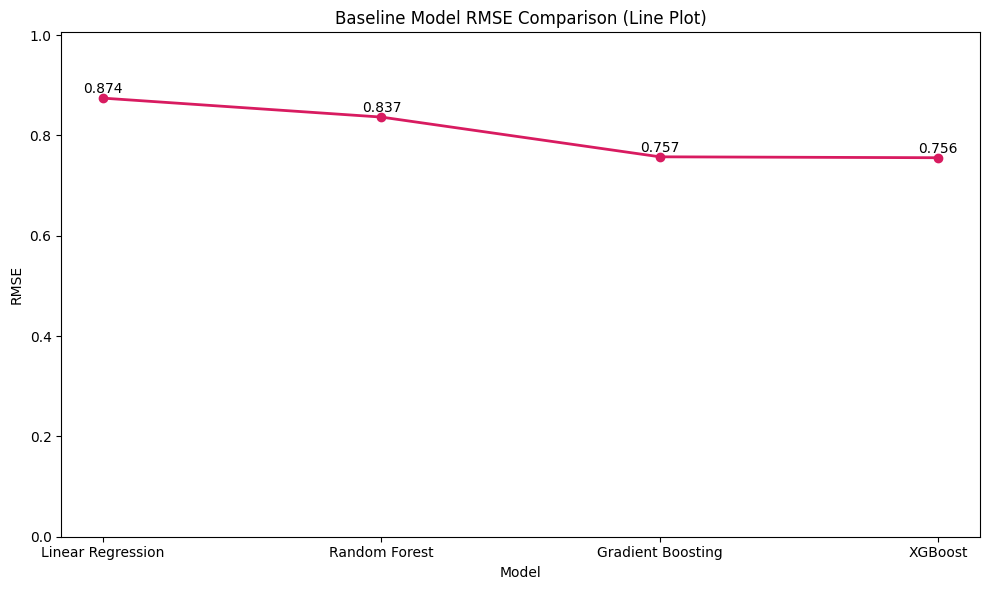

In [30]:
model_names = list(results.keys())
rmse_values = list(results.values())

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(model_names, rmse_values, marker='o', linewidth=2, color=cb_palette[0])
ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.set_title('Baseline Model RMSE Comparison (Line Plot)')
ax.set_ylim(0, max(rmse_values) * 1.15)

for i, v in enumerate(rmse_values):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### B) RMSE Comparison : Bar Chart

A bar chart gives a clearer view of the absolute magnitude of each model's error.

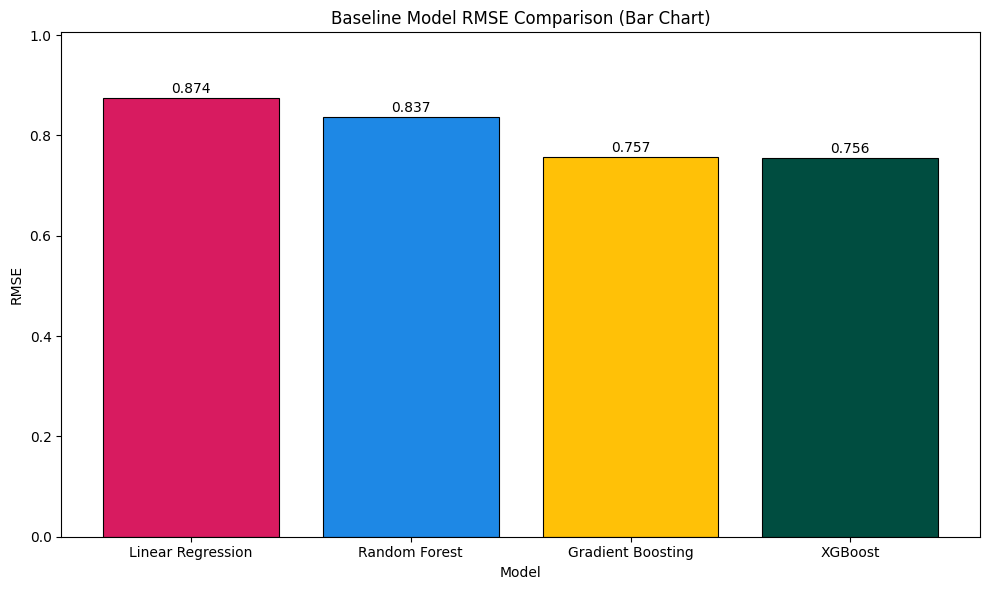

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    model_names, rmse_values,
    color=cb_palette[:len(model_names)],
    edgecolor='black',
    linewidth=0.8
)

ax.set_xlabel('Model')
ax.set_ylabel('RMSE')
ax.set_title('Baseline Model RMSE Comparison (Bar Chart)')
ax.set_ylim(0, max(rmse_values) * 1.15)

for bar, v in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.01,
        f"{v:.3f}",
        ha='center', fontsize=10
    )

plt.tight_layout()
plt.show()

## 12. Research Experiment : Learning From Limited Data in Energy Modelling
**Research Question:** *In many real-world scenarios, only limited historical energy data may be available. Developing
effective models under data scarcity is a practical challenge. This problem focuses on machine
learning approaches that perform well with small datasets. Overfitting and generalisation are
central concerns. The goal is to identify strategies that maximise learning efficiency. This
reflects constraints faced in many applied settings*

We run two experiments:
1. **Kaggle Only** – Train XGBoost on varying fractions (25%, 50%, 75%, 100%) of the Kaggle dataset
2. **Kaggle + Synthetic** – Train on the same fractions of the combined dataset

This **ablation study** reveals how much each additional source of data contributes to performance.

### A)Train on Kaggle-Only Baseline (100% of data)

In [35]:
# Kaggle-only training data
X_kaggle = kaggle[FEATURES]
y_kaggle = kaggle[TARGET]

# Train/val split
Xk_train, Xk_val, yk_train, yk_val = train_test_split(
    X_kaggle, y_kaggle, test_size=0.2, random_state=42
)

# Model
xgb_kaggle = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb_kaggle.fit(Xk_train, yk_train)

# Predictions
kaggle_preds = xgb_kaggle.predict(Xk_val)
rmse_kaggle_only = rmse(yk_val, kaggle_preds)

print(f"RMSE (Kaggle Only): {rmse_kaggle_only:.4f}")

RMSE (Kaggle Only): 0.6386


###B)Train on Kaggle + Synthetic

In [34]:
X_full = train_full[FEATURES]
y_full = train_full[TARGET]

Xf_train, Xf_val, yf_train, yf_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

xgb_full = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb_full.fit(Xf_train, yf_train)

full_preds = xgb_full.predict(Xf_val)
rmse_full = rmse(yf_val, full_preds)

print(f"RMSE (Kaggle + Synthetic): {rmse_full: .4f}")


RMSE (Kaggle + Synthetic):  0.7556


### C) Ablation Function

We train XGBoost at four different data fractions (25%, 50%, 75%, 100%) and record the validation RMSE for each.

In [36]:
def run_ablation(data, label):
    """Train XGBoost at different data fractions and return a RMSE dict.

    Parameters
    ----------
    data  : pd.DataFrame  – Full dataset (must include FEATURES and TARGET)
    label : str           – Short label used as dict key suffix

    Returns
    -------
    dict  mapping e.g. '25% Kaggle' → RMSE value
    """
    results = {}
    fractions = [0.25, 0.50, 0.75, 1.00]

    for frac in fractions:
        subset = data.sample(frac=frac, random_state=42)
        X_sub  = subset[FEATURES]
        y_sub  = subset[TARGET]

        X_tr, X_va, y_tr, y_va = train_test_split(
            X_sub, y_sub, test_size=0.2, random_state=42
        )

        model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_va)
        results[f"{int(frac*100)}% {label}"] = rmse(y_va, preds)

    return results

In [37]:
# Re-build full kaggle df with TARGET for ablation
kaggle_for_ablation = kaggle.copy()
kaggle_for_ablation[TARGET] = kaggle[TARGET]   # already present

ablation_kaggle = run_ablation(kaggle_for_ablation, "Kaggle")
print("Kaggle-only ablation results:")
for k, v in ablation_kaggle.items():
    print(f"  {k}: RMSE = {v:.4f}")

Kaggle-only ablation results:
  25% Kaggle: RMSE = 0.6441
  50% Kaggle: RMSE = 0.6432
  75% Kaggle: RMSE = 0.6437
  100% Kaggle: RMSE = 0.6387


In [38]:
ablation_full = run_ablation(train_full, "Kaggle+Synthetic")
print("Kaggle + Synthetic ablation results:")
for k, v in ablation_full.items():
    print(f"  {k}: RMSE = {v:.4f}")

Kaggle + Synthetic ablation results:
  25% Kaggle+Synthetic: RMSE = 0.8658
  50% Kaggle+Synthetic: RMSE = 0.7957
  75% Kaggle+Synthetic: RMSE = 0.7687
  100% Kaggle+Synthetic: RMSE = 0.7511


### D) Ablation Plot – RMSE vs Training Data Size

The plot below compares how RMSE evolves as we increase the amount of training data for both the Kaggle-only and the combined datasets.

**Key takeaways to discuss in the report:**
- Does the synthetic data help or hurt when Kaggle data is abundant?
- At low data fractions (25%), does augmentation have a more pronounced effect?

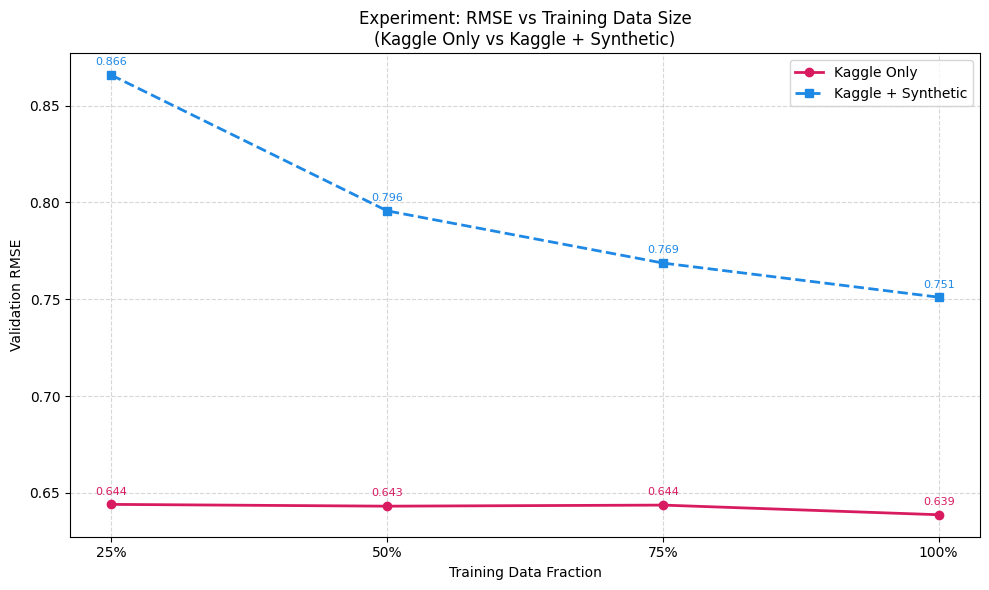

In [40]:
sizes = ["25%", "50%", "75%", "100%"]

kaggle_rmse = [ablation_kaggle[f"{s} Kaggle"] for s in sizes]
full_rmse   = [ablation_full[f"{s} Kaggle+Synthetic"] for s in sizes]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(sizes, kaggle_rmse, marker='o', linewidth=2,
        label="Kaggle Only",          color=cb_palette[0])
ax.plot(sizes, full_rmse,  marker='s', linewidth=2, linestyle='--',
        label="Kaggle + Synthetic",   color=cb_palette[1])

ax.set_xlabel("Training Data Fraction")
ax.set_ylabel("Validation RMSE")
ax.set_title("Experiment: RMSE vs Training Data Size\n(Kaggle Only vs Kaggle + Synthetic)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Annotate each point
for i, (k, f) in enumerate(zip(kaggle_rmse, full_rmse)):
    ax.text(i, k + 0.005, f"{k:.3f}", ha='center', fontsize=8, color=cb_palette[0])
    ax.text(i, f + 0.005, f"{f:.3f}", ha='center', fontsize=8, color=cb_palette[1])

plt.tight_layout()
plt.show()

## 13. Final Model Training & Submission

Based on the experimental results, **XGBoost** is the best-performing model.

We now:
1. Re-train it on the **full combined training set** (Kaggle + Synthetic) with more estimators and a lower learning rate for better convergence
2. Generate predictions on the **test set**
3. Export a CSV in the competition submission format: Household_ID, Energy_Consumption_kWh

In [41]:
X_final = train_full[FEATURES]
y_final = train_full[TARGET]

best_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.001,
    max_depth=6,
)

best_model.fit(X_final, y_final)
print("Final model trained successfully.")

test_preds = best_model.predict(test_model[FEATURES])
print(f"Predictions generated for {len(test_preds)} test samples.")

Final model trained successfully.
Predictions generated for 390 test samples.


In [42]:
submission = pd.DataFrame({
    'Household_ID':           test['Household_ID'],
    'Energy_Consumption_kWh': test_preds
})

submission.to_csv("submission.csv", index=False)
print("Submission saved to 'submission.csv'")
print(f"Submission shape: {submission.shape}")
submission.head()

Submission saved to 'submission.csv'
Submission shape: (390, 2)


,Household_ID,Energy_Consumption_kWh
0,S108,5.071912
1,S60,3.855359
2,S587,3.805469
3,S537,4.103486
4,S101,2.157466
